In [1]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# Cell 2 — synthetic fraud-like dataset
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=20000, n_features=10, n_informative=6,
    weights=[0.95, 0.05],  # ~5% fraud, like real fraud data
    flip_y=0.01, random_state=42
)

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(10)])
df["is_fraud"] = y
df["time_step"] = np.arange(len(df))  # pretend this is chronological order

df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,is_fraud,time_step
0,0.320369,-0.520241,0.226862,-1.934781,-1.947447,-2.051393,0.262367,-0.900924,-1.498455,-2.294892,0,0
1,0.171203,-1.328328,-0.464534,-0.586279,-1.261397,-3.252064,1.153607,-2.241961,0.616120,-1.538542,0,1
2,-1.503444,2.957689,-1.134412,1.351797,0.388065,1.924340,-1.260189,-0.472208,0.039989,-1.761144,0,2
3,-1.680857,1.315571,-1.084441,0.927292,-1.636048,-0.697179,-1.859559,-0.984415,1.393748,0.368163,0,3
4,0.258858,1.332051,-0.365772,-2.923181,-2.768885,-0.353311,0.375830,0.366101,1.682550,-3.280432,0,4


In [3]:
# Cell 3
df = df.sort_values("time_step").reset_index(drop=True)
print(df.shape)

(20000, 12)


In [4]:
# Cell 4
n = len(df)
pre_shift        = df.iloc[: int(n*0.5)].copy()
post_shift_early = df.iloc[int(n*0.5): int(n*0.75)].copy()
post_shift_late  = df.iloc[int(n*0.75):].copy()

print("pre_shift:", pre_shift.shape)
print("post_shift_early:", post_shift_early.shape)
print("post_shift_late:", post_shift_late.shape)

pre_shift: (10000, 12)
post_shift_early: (5000, 12)
post_shift_late: (5000, 12)


In [5]:
# Cell 5
# Shift the distribution of a couple of features to simulate new fraud behavior
drift_features = ["feature_0", "feature_1"]

for f in drift_features:
    post_shift_early[f] = post_shift_early[f] + 1.0   # small shift
    post_shift_late[f]  = post_shift_late[f] + 2.5     # bigger shift, further from original

# Also make fraud slightly more common in the "new world" — new fraud wave
def inject_more_fraud(chunk, boost=0.03):
    flip_idx = chunk[chunk["is_fraud"] == 0].sample(frac=boost, random_state=1).index
    chunk.loc[flip_idx, "is_fraud"] = 1
    return chunk

post_shift_early = inject_more_fraud(post_shift_early, boost=0.02)
post_shift_late  = inject_more_fraud(post_shift_late, boost=0.05)

print("Fraud rate pre-shift:", pre_shift["is_fraud"].mean())
print("Fraud rate post_shift_early:", post_shift_early["is_fraud"].mean())
print("Fraud rate post_shift_late:", post_shift_late["is_fraud"].mean())

Fraud rate pre-shift: 0.055
Fraud rate post_shift_early: 0.0736
Fraud rate post_shift_late: 0.1018


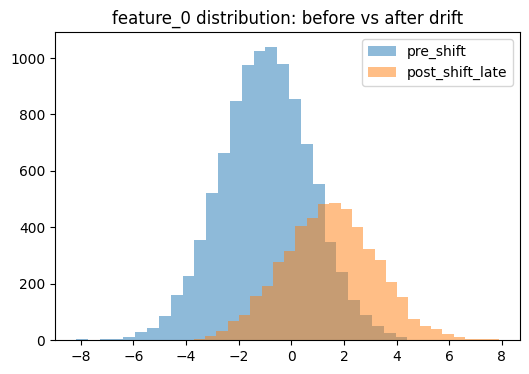

In [6]:
# Cell 6
plt.figure(figsize=(6,4))
plt.hist(pre_shift["feature_0"], bins=30, alpha=0.5, label="pre_shift")
plt.hist(post_shift_late["feature_0"], bins=30, alpha=0.5, label="post_shift_late")
plt.legend()
plt.title("feature_0 distribution: before vs after drift")
plt.show()

In [7]:
# Cell 7
pre_shift.to_csv("pre_shift.csv", index=False)
post_shift_early.to_csv("post_shift_early.csv", index=False)
post_shift_late.to_csv("post_shift_late.csv", index=False)

from google.colab import files
files.download("pre_shift.csv")
files.download("post_shift_early.csv")
files.download("post_shift_late.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>